# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


Text(0.5, 0, ' ')

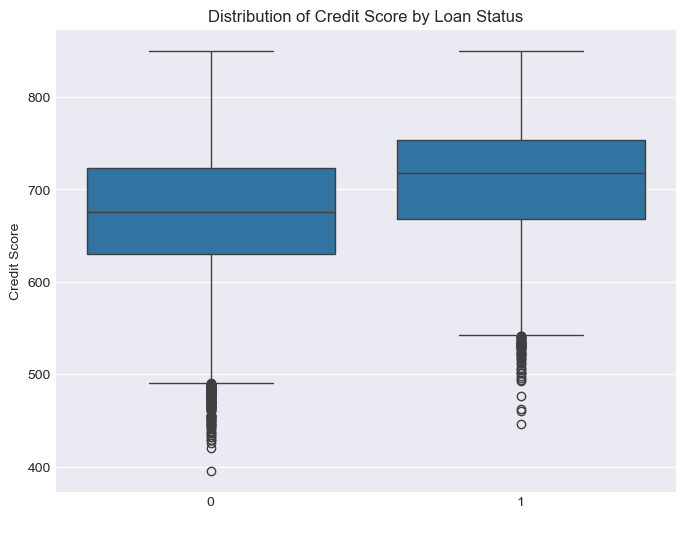

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Distribution of Credit Score by Loan Status')
plt.ylabel('Credit Score')
plt.xlabel(' ')

Text(0.5, 0, ' ')

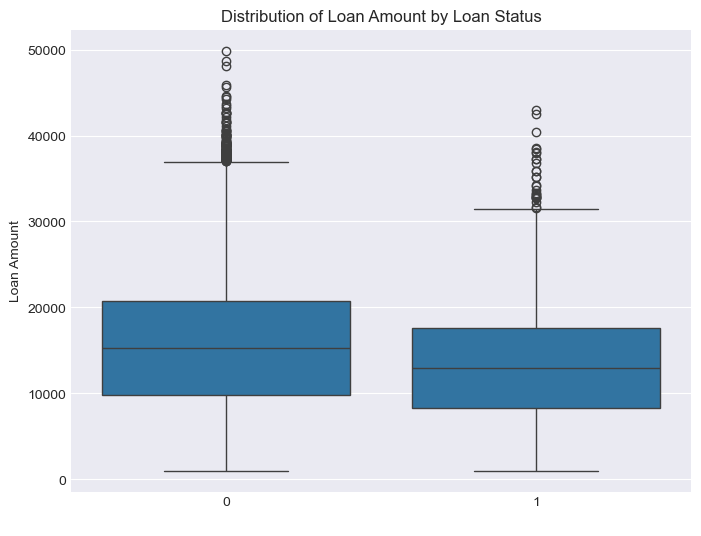

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Distribution of Loan Amount by Loan Status')
plt.ylabel('Loan Amount')
plt.xlabel(' ')

Text(0.5, 0, ' ')

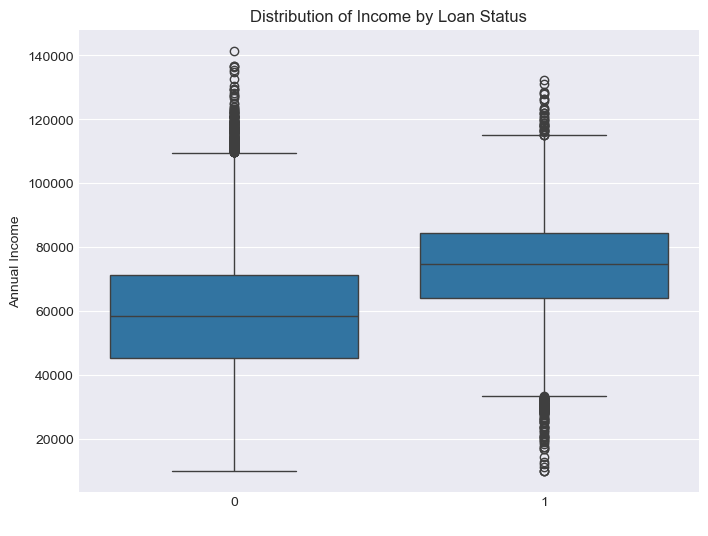

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Distribution of Income by Loan Status')
plt.ylabel('Annual Income')
plt.xlabel(' ')

Text(0.5, 0, ' ')

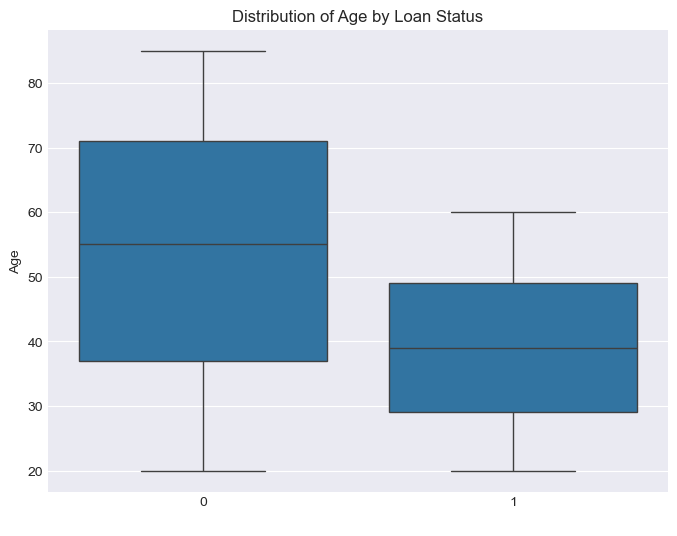

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='person_age', data=df)
plt.title('Distribution of Age by Loan Status')
plt.ylabel('Age')
plt.xlabel(' ')

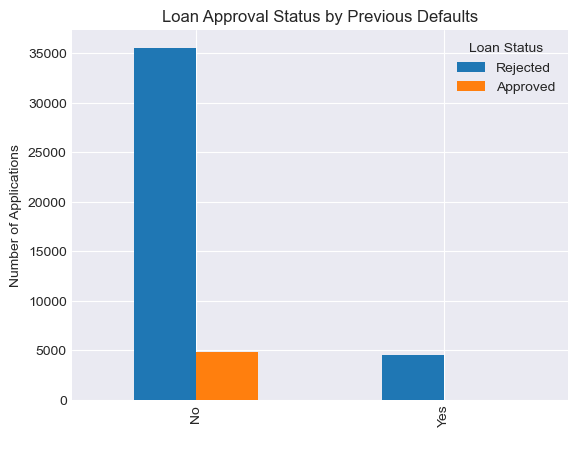

In [21]:
cross_tab_default = pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'])
cross_tab_default.plot(kind='bar')
plt.title('Loan Approval Status by Previous Defaults')
plt.ylabel('Number of Applications')
plt.xlabel(' ')
plt.legend(['Rejected', 'Approved'], title='Loan Status')
default_labels = sorted(df['previous_loan_defaults_on_file'].unique())

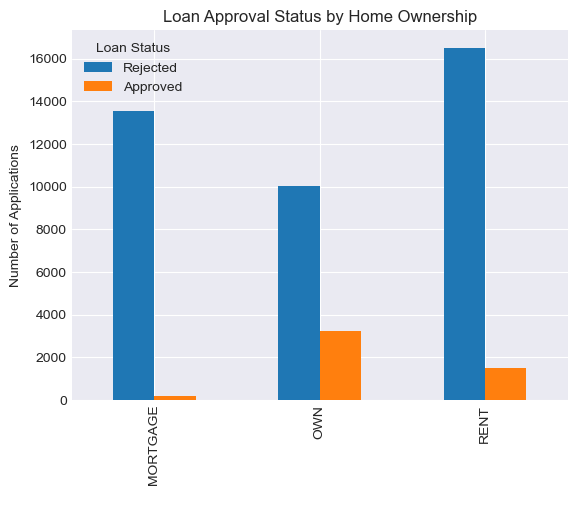

In [22]:
cross_tab_home = pd.crosstab(df['person_home_ownership'], df['loan_status'])
cross_tab_home.plot(kind='bar')
plt.title('Loan Approval Status by Home Ownership')
plt.ylabel('Number of Applications')
plt.xlabel(' ')
plt.legend(['Rejected', 'Approved'], title='Loan Status')
home_labels = sorted(df['person_home_ownership'].unique())

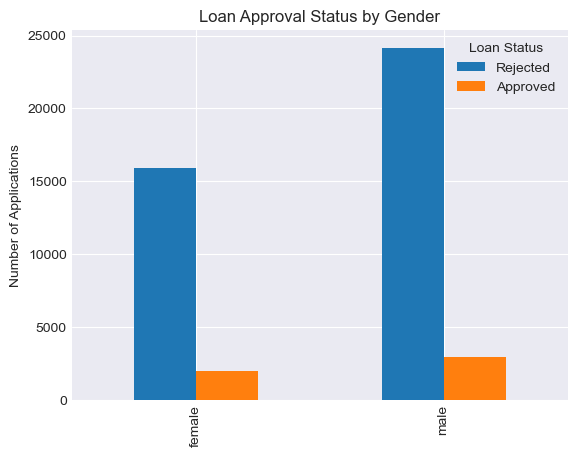

In [ ]:
cross_tab_gender = pd.crosstab(df['person_gender'], df['loan_status'])
cross_tab_gender.plot(kind='bar')
plt.title('Loan Approval Status by Gender')
plt.ylabel('Number of Applications')
plt.xlabel(' ')
plt.legend(['Rejected', 'Approved'], title='Loan Status')
label_positions = [0, 1]
custom_labels = ['Female', 'Male']

1. Which features drive the model's decision?
Previous Loan Defaults: This is the strongest driver. The proportion plot shows that applicants with a "Yes" for previous defaults have a $0\%$ approval rate.Person Income & Credit Score: The boxplots show that approved applicants (Status $1$) have significantly higher median incomes and higher credit scores than those rejected.Home Ownership: Applicants who "OWN" their home have a much higher likelihood of approval compared to those with a "MORTGAGE".

2. Which seem unrelated?
Person Gender: The approval proportions for males and females are virtually identical (around $11\%$). This indicates gender is not a predictive factor for the model.Loan Amount: While there is some difference, the overlap in the boxplots suggests it is a weaker driver compared to income or credit history.

3. Should the institution be concerned about legal trouble?
Yes, specifically regarding Age. * Justification: The boxplot for person_age shows a massive disparity. The median age for approved loans is significantly lower (approx. $39$ years) than for rejected loans (approx. $54$ years). Under the Equal Credit Opportunity Act (ECOA), it is illegal to discriminate based on age. The data suggests the model heavily favors younger applicants, which could be legally interpreted as age discrimination.